Первые 10 записей из базы данных SQLite:
         Date  Adj Close      Close       High        Low       Open  \
0  2019-05-10  41.570000  41.570000  45.000000  41.060001  42.000000   
1  2019-05-13  37.099998  37.099998  39.240002  36.080002  38.790001   
2  2019-05-14  39.959999  39.959999  39.959999  36.849998  38.310001   
3  2019-05-15  41.290001  41.290001  41.880001  38.950001  39.369999   
4  2019-05-16  43.000000  43.000000  44.060001  41.250000  41.480000   
5  2019-05-17  41.910000  41.910000  43.290001  41.270000  41.980000   
6  2019-05-20  41.590000  41.590000  41.680000  39.459999  41.189999   
7  2019-05-21  41.500000  41.500000  42.240002  41.250000  42.000000   
8  2019-05-22  41.250000  41.250000  41.279999  40.500000  41.049999   
9  2019-05-23  40.470001  40.470001  41.090000  40.020000  40.799999   

      Volume  
0  186322500  
1   79442400  
2   46661100  
3   36086100  
4   38115500  
5   20225700  
6   29222300  
7   10802900  
8    9089500  
9   11119900  



-> Интерактивный свечной график открыт в браузере.


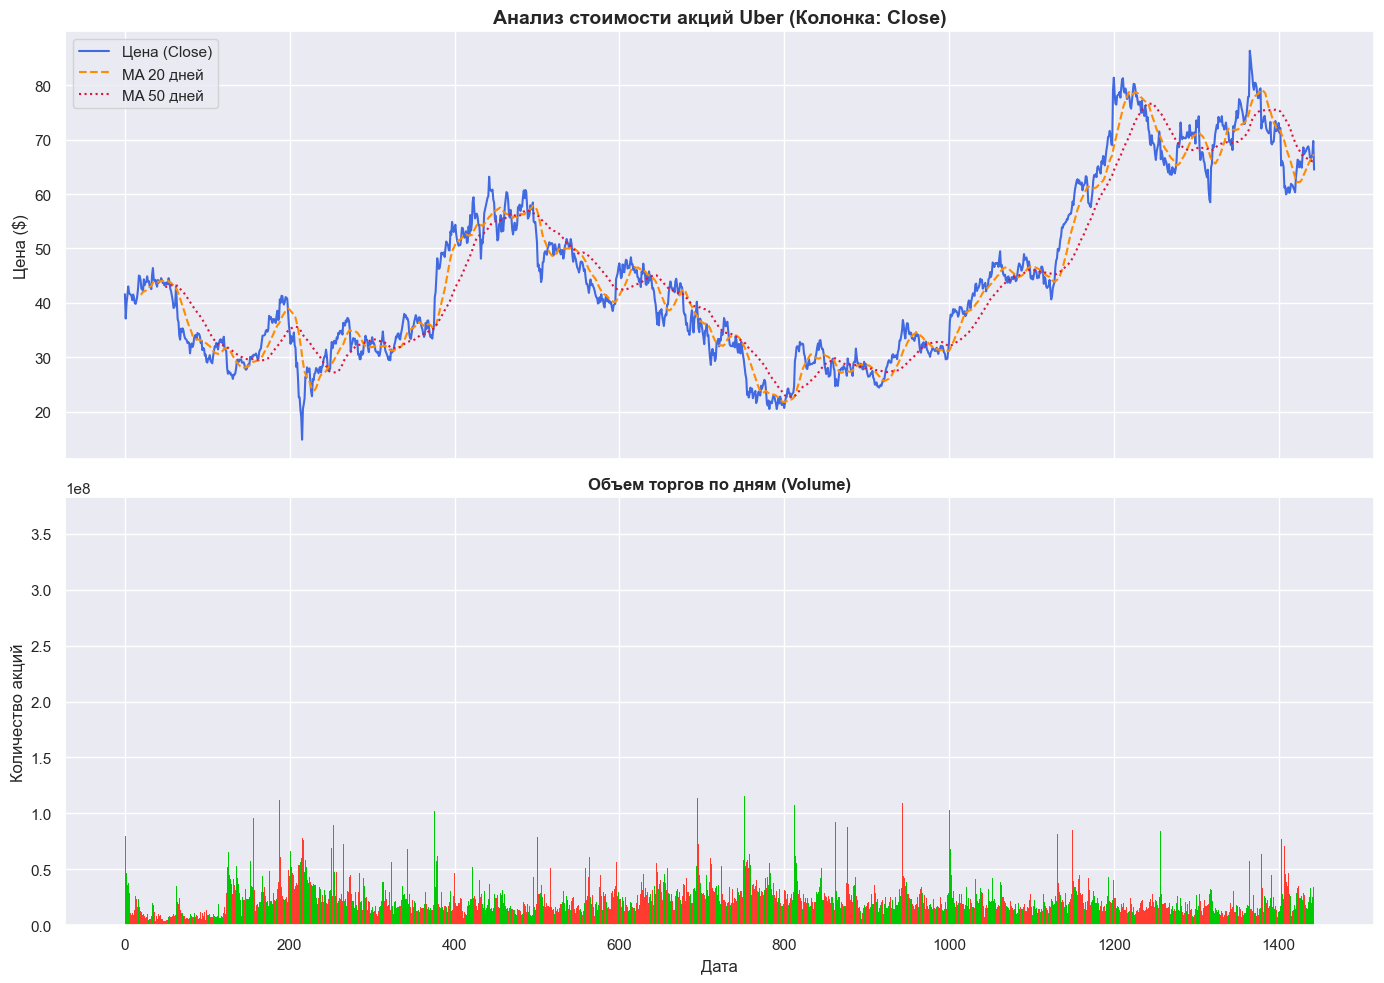

-> Статические графики тренда и объемов выведены на экран.

ПРЕДОБРАБОТКА ДАННЫХ АКЦИЙ UBER
Пропущенные значения:
Series([], dtype: int64)
Дубликатов до очистки: 0
Дубликатов после очистки: 0
Категориальные колонки: ['Date']
Date: 1444 уникальных значений
Типы данных после оптимизации:
Date           int16
Adj Close    float32
Close        float32
High         float32
Low          float32
Open         float32
Volume         int32
dtype: object


In [1]:
from data_load import *
from data_processing import *
from data_visual import *


create_table_in_db_uber()
describe_uber_stocks()
df = load_data_from_db()
create_visualizations_uber(df)
df_proc = processing_uber(df)


ПРЕДОБРАБОТКА ДАННЫХ АКЦИЙ UBER

СРАВНЕНИЕ МОДЕЛЕЙ
LASSO -> MAE: 1.22 | RMSE: 1.79 | R2: 0.9072
ARIMA -> MAE: 1.17 | RMSE: 1.74 | R2: 0.9132
Lasso прогноз на завтра: 69.27
ARIMA прогноз на завтра: 64.60


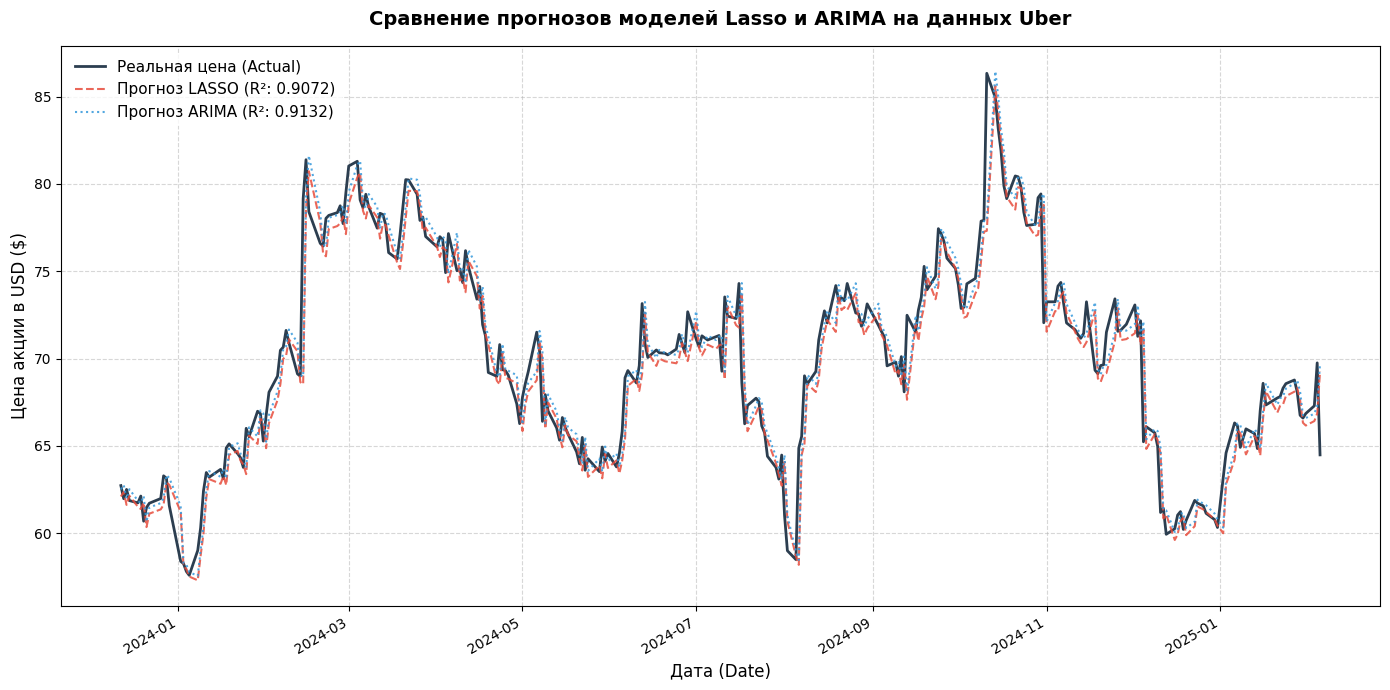

In [1]:
import sqlite3
import warnings
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from data_visual import *
from data_processing import *

# Отключаем предупреждения сходимости ARIMA для чистых логов
warnings.filterwarnings("ignore")

# ==========================================
# Загрузка и базовая подготовка
# ==========================================
conn = sqlite3.connect("uber_stocks.db")
df = pd.read_sql_query("SELECT * FROM stocks", conn)
conn.close()

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df = processing_uber_arima_lasso(df)

# Для ARIMA нам нужен чистый временной ряд с датой в качестве индекса
df_arima = df.copy().set_index("Date")["Close"]

# ==========================================
# Подход 1: Модель LASSO
# ==========================================
df_lasso = df.copy()
df_lasso["target"] = df_lasso["Close"].shift(-1)

# Создание лагов
df_lasso["close_lag1"] = df_lasso["Close"].shift(0)
df_lasso["close_lag2"] = df_lasso["Close"].shift(1)
df_lasso["volume_lag1"] = df_lasso["Volume"].shift(0)
df_lasso["rolling_mean_5"] = df_lasso["Close"].rolling(window=5).mean()
df_lasso = df_lasso.dropna().reset_index(drop=True)

feature_cols = ["close_lag1", "close_lag2", "volume_lag1", "rolling_mean_5"]
X = df_lasso[feature_cols]
y = df_lasso["target"]

# Хронологический сплит (80 / 20)
split_idx = int(len(df_lasso) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Масштабирование признаков (критично для Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение Lasso
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# Оценка Lasso
lasso_preds = lasso_model.predict(X_test_scaled)
lasso_mae = mean_absolute_error(y_test, lasso_preds)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_preds))
lasso_r2 = r2_score(y_test, lasso_preds)

# ==========================================
# Подход 2: Модель ARIMA
# ==========================================
# Разделение ряда на train/test по той же пропорции
arima_split = int(len(df_arima) * 0.8)
arima_train = df_arima.iloc[:arima_split]
arima_test = df_arima.iloc[arima_split:]

# Обучаем ARIMA(p,d,q). Параметры (1, 1, 1) — базовый стандарт для акций
# (1 лаг авторегрессии, 1 разность для стационарности, 1 лаг ошибки)
arima_model = ARIMA(arima_train, order=(1, 1, 1))
arima_result = arima_model.fit()

# Для честной оценки на тесте используем rolling-прогноз (модель узнает факт дня Т перед прогнозом Т+1)
history = [x for x in arima_train]
arima_preds = []

for t in range(len(arima_test)):
    model_step = ARIMA(history, order=(1, 1, 1))
    model_step_fitted = model_step.fit()
    output = model_step_fitted.forecast()
    arima_preds.append(output[0])
    history.append(arima_test.iloc[t])

arima_mae = mean_absolute_error(arima_test, arima_preds)
arima_rmse = np.sqrt(mean_squared_error(arima_test, arima_preds))
arima_r2 = r2_score(arima_test, arima_preds)

# ==========================================
# Вывод результатов сравнения
# ==========================================
print("\n" + "=" * 50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 50)
print(f"LASSO -> MAE: {lasso_mae:.2f} | RMSE: {lasso_rmse:.2f} | R2: {lasso_r2:.4f}")
print(f"ARIMA -> MAE: {arima_mae:.2f} | RMSE: {arima_rmse:.2f} | R2: {arima_r2:.4f}")
print("=" * 50)

# ==========================================
# Прогноз на следующий торговый день
# ==========================================
# 1. Прогноз Lasso
last_row = df_lasso.iloc[-1]
next_features = pd.DataFrame(
    [
        {
            "close_lag1": last_row["Close"],
            "close_lag2": last_row["close_lag1"],
            "volume_lag1": last_row["Volume"],
            "rolling_mean_5": df_lasso["Close"].tail(5).mean(),
        }
    ]
)
next_features_scaled = scaler.transform(next_features)
lasso_next_pred = lasso_model.predict(next_features_scaled)[0]

# 2. Прогноз ARIMA
final_arima_model = ARIMA(df_arima, order=(1, 1, 1))
final_arima_fitted = final_arima_model.fit()
arima_next_pred = float(final_arima_fitted.forecast().iloc[0])

# Принудительно приводим прогноз Lasso к числу, извлекая элемент правильно
lasso_val = float(np.ravel(lasso_next_pred)[0])

print(f"Lasso прогноз на завтра: {lasso_val:.2f}")
print(f"ARIMA прогноз на завтра: {arima_next_pred:.2f}")

# Преобразуем arima_preds в одномерный массив (на случай, если это был список списков)
arima_preds_flat = np.ravel(arima_preds)
# ==========================================
# 8. Функция визуализации результатов
# ==========================================
plot_stock_predictions(
    dates=arima_test.index,
    y_true=arima_test.values,
    lasso_predictions=lasso_preds,
    arima_predictions=arima_preds,
    r2_l=lasso_r2,
    r2_a=arima_r2
)
